# 03 - Teorema de Bayes (implementacao manual)

Responsavel: Integrante 3

Objetivo: calcular P(Classe | Atributos) na mao, demonstrando compreensao das etapas: priori, verossimilhanca e posteriori. So depois comparar com o scikit-learn.

In [20]:
import os

REPO_PATH = '/content/super-projeto-de-probabilidade-estatistica'

if not os.path.exists(REPO_PATH):
    !git clone https://github.com/Lucas-oss444/super-projeto-de-probabilidade-estatistica.git

os.chdir(REPO_PATH)
!git pull
print('CWD:', os.getcwd())

Already up to date.
CWD: /content/super-projeto-de-probabilidade-estatistica


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('data/dataset_tratado.csv')
print('Shape:', df.shape)
df.head()

Shape: (149999, 10)


,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,alvo,sem_vtat,hora,dia_semana,mes,periodo_dia
0,eBike,Palam Vihar,Jhilmil,8.3,0,1,12,5,3,tarde
1,Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,0,0,18,4,11,noite
2,Auto,Khandsa,Malviya Nagar,13.4,1,0,8,4,8,manha
3,Premier Sedan,Central Secretariat,Inderlok,13.1,1,0,17,0,10,tarde
4,Bike,Ghitorni Village,Khan Market,5.3,1,0,22,0,9,noite


## 1. Divisao treino/teste (estratificada)

In [22]:
# Preditoras discretas: ideais para contagem de verossimilhança
PREDITORAS = ['Vehicle Type', 'periodo_dia', 'sem_vtat']
ALVO = 'alvo'

X = df[PREDITORAS]
y = df[ALVO]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Treino: {len(X_train):,} amostras  |  Teste: {len(X_test):,} amostras')
vc = y_train.value_counts(normalize=True).sort_index()
print(f'\nDistribuição no treino:')
print(f'  Não Concluída (0): {vc[0]:.1%}')
print(f'  Concluída     (1): {vc[1]:.1%}')

Treino: 119,999 amostras  |  Teste: 30,000 amostras

Distribuição no treino:
  Não Concluída (0): 38.0%
  Concluída     (1): 62.0%


## 2. Probabilidades a priori P(C)

In [23]:
priori = y_train.value_counts(normalize=True).sort_index().to_dict()

print('Probabilidades a priori P(C):')
print(f'  P(Não Concluída) = {priori[0]:.4f}  ({priori[0]:.1%})')
print(f'  P(Concluída)     = {priori[1]:.4f}  ({priori[1]:.1%})')

Probabilidades a priori P(C):
  P(Não Concluída) = 0.3800  (38.0%)
  P(Concluída)     = 0.6200  (62.0%)


## 3. Verossimilhancas P(X_i | C) com suavizacao de Laplace

In [24]:
def calcular_verossimilhancas(X_tr, y_tr, preditoras):
    """Calcula P(X_i = v | C) com suavização de Laplace (alpha=1)."""
    tabelas = {}
    classes = sorted(y_tr.unique())

    for col in preditoras:
        tabelas[col] = {}
        categorias = X_tr[col].unique()
        n_cats = len(categorias)

        for c in classes:
            subset = X_tr[y_tr == c][col]
            n_classe = len(subset)
            tabelas[col][c] = {
                cat: (int((subset == cat).sum()) + 1) / (n_classe + n_cats)
                for cat in categorias
            }
    return tabelas

verossimilhanca = calcular_verossimilhancas(X_train, y_train, PREDITORAS)

print('P(Vehicle Type | Classe) com suavização de Laplace:')
vt = pd.DataFrame({
    'P(·|Não Concluída)': verossimilhanca['Vehicle Type'][0],
    'P(·|Concluída)':     verossimilhanca['Vehicle Type'][1],
}).round(4).sort_values('P(·|Concluída)', ascending=False)
print(vt)

print('\nP(periodo_dia | Classe):')
pt = pd.DataFrame({
    'P(·|Não Concluída)': verossimilhanca['periodo_dia'][0],
    'P(·|Concluída)':     verossimilhanca['periodo_dia'][1],
}).round(4)
print(pt)

print('\nP(sem_vtat | Classe):')
sv = pd.DataFrame({
    'P(·|Não Concluída)': verossimilhanca['sem_vtat'][0],
    'P(·|Concluída)':     verossimilhanca['sem_vtat'][1],
}, index=['sem motorista (1)', 'com motorista (0)']).round(4)
print(sv)

P(Vehicle Type | Classe) com suavização de Laplace:
               P(·|Não Concluída)  P(·|Concluída)
Auto                       0.2511          0.2490
Go Mini                    0.1977          0.1989
Go Sedan                   0.1821          0.1789
Bike                       0.1489          0.1516
Premier Sedan              0.1195          0.1215
eBike                      0.0710          0.0703
Uber XL                    0.0296          0.0298

P(periodo_dia | Classe):
           P(·|Não Concluída)  P(·|Concluída)
tarde                  0.3248          0.3224
noite                  0.3102          0.3106
manha                  0.3016          0.3037
madrugada              0.0634          0.0633

P(sem_vtat | Classe):
                   P(·|Não Concluída)  P(·|Concluída)
sem motorista (1)                 NaN             NaN
com motorista (0)                 NaN             NaN


## 4. Posteriori P(C | X) - hipotese Naive Bayes

In [25]:
def prever_bayes(X_df, priori, verossimilhanca, preditoras):
    """Prediz usando log-probabilidades para evitar underflow numérico."""
    classes = sorted(priori.keys())
    log_scores = {}

    for c in classes:
        log_s = np.full(len(X_df), np.log(priori[c]))
        for col in preditoras:
            mapper = verossimilhanca[col][c]
            probs = X_df[col].map(mapper).fillna(1e-6).clip(lower=1e-10)
            log_s = log_s + np.log(probs.values)
        log_scores[c] = log_s

    scores_df = pd.DataFrame(log_scores, index=X_df.index)
    return scores_df.idxmax(axis=1)

y_pred = prever_bayes(X_test, priori, verossimilhanca, PREDITORAS)

print('Exemplos de previsão (10 primeiros):')
comparacao = pd.DataFrame({
    'Real':     y_test.values[:10],
    'Previsto': y_pred.values[:10],
    'Correto':  (y_test.values[:10] == y_pred.values[:10]),
})
print(comparacao.to_string(index=False))

Exemplos de previsão (10 primeiros):
 Real  Previsto  Correto
    1         1     True
    0         1    False
    0         1    False
    0         1    False
    1         1     True
    0         1    False
    1         1     True
    1         1     True
    1         1     True
    1         1     True


## 5. Avaliacao e interpretacao

=== MÉTRICAS — NAIVE BAYES MANUAL ===
Acurácia:  0.6862 (68.6%)
Precisão:  0.6640 (66.4%)
Recall:    1.0000 (100.0%)
F1-Score:  0.7981

               precision    recall  f1-score   support

Não Concluída       1.00      0.17      0.30     11400
    Concluída       0.66      1.00      0.80     18600

     accuracy                           0.69     30000
    macro avg       0.83      0.59      0.55     30000
 weighted avg       0.79      0.69      0.61     30000



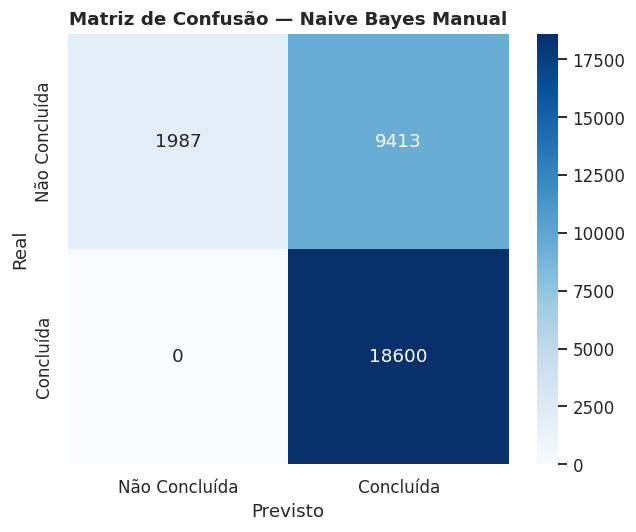

In [26]:
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)

print('=== MÉTRICAS — NAIVE BAYES MANUAL ===')
print(f'Acurácia:  {acc:.4f} ({acc:.1%})')
print(f'Precisão:  {prec:.4f} ({prec:.1%})')
print(f'Recall:    {rec:.4f} ({rec:.1%})')
print(f'F1-Score:  {f1:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Não Concluída', 'Concluída']))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Concluída', 'Concluída'],
            yticklabels=['Não Concluída', 'Concluída'], ax=ax)
ax.set_title('Matriz de Confusão — Naive Bayes Manual', fontsize=12, fontweight='bold')
ax.set_ylabel('Real')
ax.set_xlabel('Previsto')
plt.tight_layout()
plt.show()

## 6. Validacao com scikit-learn (opcional)

In [27]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.naive_bayes import CategoricalNB

enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train_enc = enc.fit_transform(X_train.astype(str))
X_test_enc  = enc.transform(X_test.astype(str))

nb_sk = CategoricalNB(alpha=1.0)  # alpha=1 = suavização de Laplace
nb_sk.fit(X_train_enc, y_train)
y_pred_sk = nb_sk.predict(X_test_enc)

acc_sk = accuracy_score(y_test, y_pred_sk)
f1_sk  = f1_score(y_test, y_pred_sk, zero_division=0)

print('=== COMPARAÇÃO: MANUAL vs SCIKIT-LEARN ===')
print(f'Acurácia — implementação manual:  {acc:.4f}')
print(f'Acurácia — CategoricalNB sklearn: {acc_sk:.4f}')
print(f'F1-Score — implementação manual:  {f1:.4f}')
print(f'F1-Score — CategoricalNB sklearn: {f1_sk:.4f}')
diff = abs(acc - acc_sk)
status = 'equivalentes ✓' if diff < 0.005 else 'verificar implementação'
print(f'\nDiferença de acurácia: {diff:.6f} — {status}')

=== COMPARAÇÃO: MANUAL vs SCIKIT-LEARN ===
Acurácia — implementação manual:  0.6862
Acurácia — CategoricalNB sklearn: 0.6862
F1-Score — implementação manual:  0.7981
F1-Score — CategoricalNB sklearn: 0.7981

Diferença de acurácia: 0.000000 — equivalentes ✓
